# EDA Analysis of Dental Xray Data

### Import and Setup

In [ ]:
%pip install opencv-python

In [2]:
import os
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter


### Load Images

In [3]:
DATA_DIR = "quadrant-enumeration-disease/xrays"

image_files = [
    f for f in os.listdir(DATA_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Total images found:", len(image_files))


Total images found: 705


#### corrupt images detection

In [4]:
corrupted = []

for img_name in image_files:
    try:
        img = Image.open(os.path.join(DATA_DIR, img_name))
        img.verify()
    except:
        corrupted.append(img_name)

print("Corrupted images:", len(corrupted))


Corrupted images: 0


#### visual sanity check

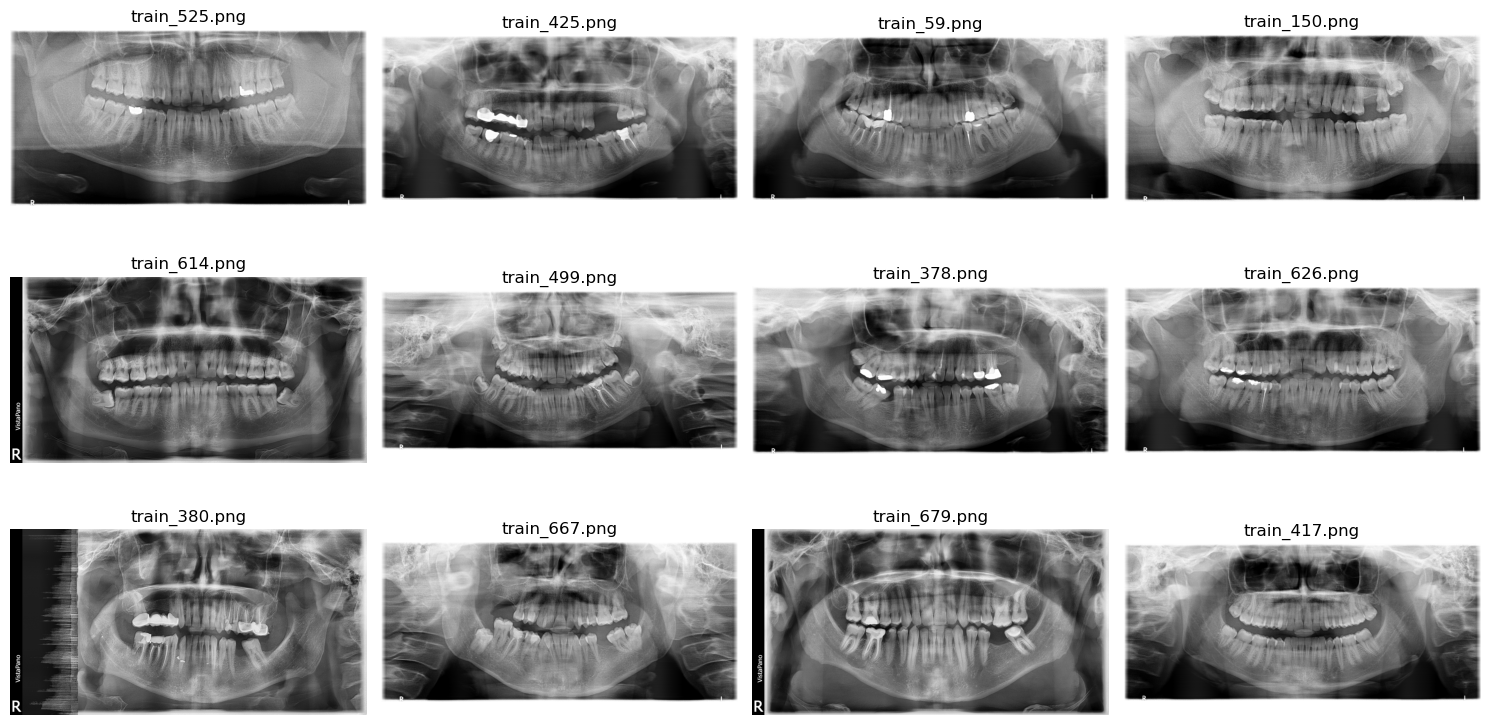

In [5]:
import random

def show_random_images(img_list, n=12):
    samples = random.sample(img_list, n)
    plt.figure(figsize=(15, 8))

    for i, img_name in enumerate(samples):
        img_path = os.path.join(DATA_DIR, img_name)
        img = Image.open(img_path).convert("L")

        plt.subplot(3, 4, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(img_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images(image_files)


### Image size and Aspect Ratio

In [6]:
sizes = []

for img_name in image_files:
    img = Image.open(os.path.join(DATA_DIR, img_name))
    sizes.append(img.size)  # (width, height)

sizes = np.array(sizes)

print("Min (W,H):", sizes.min(axis=0))
print("Max (W,H):", sizes.max(axis=0))
print("Mean (W,H):", sizes.mean(axis=0))


Min (W,H): [1976  976]
Max (W,H): [3139 1536]
Mean (W,H): [2830.27801418 1366.62695035]


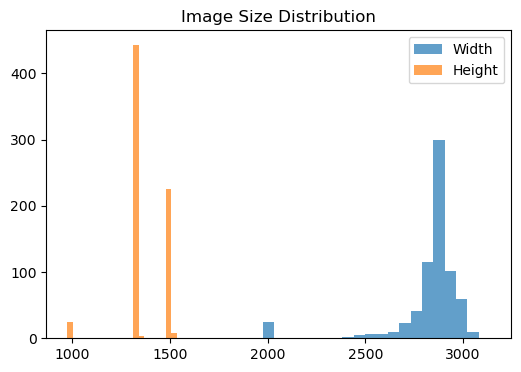

In [7]:
plt.figure(figsize=(6,4))
plt.hist(sizes[:,0], bins=20, alpha=0.7, label="Width")
plt.hist(sizes[:,1], bins=20, alpha=0.7, label="Height")
plt.legend()
plt.title("Image Size Distribution")
plt.show()


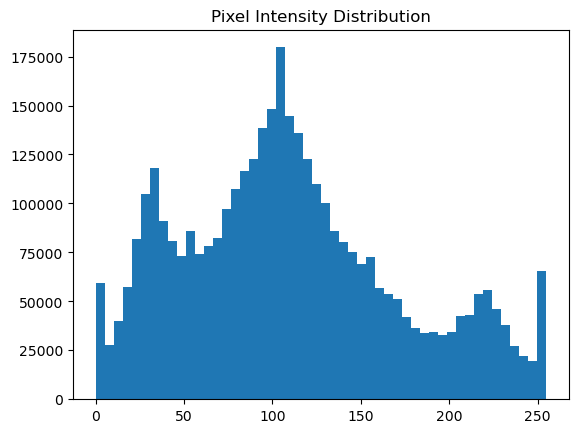

In [8]:
def plot_intensity(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    plt.hist(img.flatten(), bins=50)
    plt.title("Pixel Intensity Distribution")
    plt.show()

plot_intensity(os.path.join(DATA_DIR, image_files[0]))


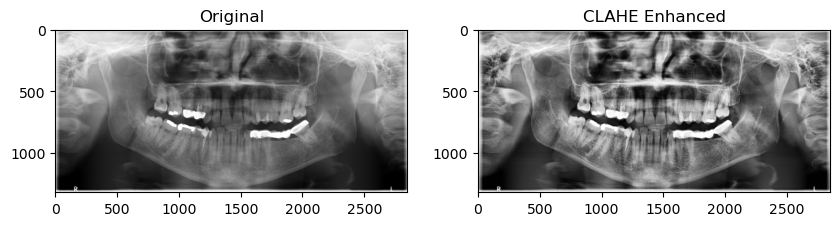

In [9]:
def show_contrast_versions(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(img)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(enhanced, cmap="gray")
    plt.title("CLAHE Enhanced")

    plt.show()

show_contrast_versions(os.path.join(DATA_DIR, image_files[0]))


In [10]:
import hashlib

def get_hash(img_path):
    with open(img_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

for img_name in image_files:
    img_path = os.path.join(DATA_DIR, img_name)
    h = get_hash(img_path)
    if h in hashes:
        duplicates.append(img_name)
    else:
        hashes[h] = img_name

print("Duplicate images found:", len(duplicates))


Duplicate images found: 0


In [14]:
import json

with open("quadrant-enumeration-disease\\train_quadrant_enumeration_disease.json", "r") as f:
    data = json.load(f)

print(data.keys())


dict_keys(['images', 'annotations', 'categories_1', 'categories_2', 'categories_3'])


In [15]:
data["annotations"][0]


{'iscrowd': 0,
 'image_id': 1,
 'bbox': [542.0, 698.0, 220.0, 271.0],
 'segmentation': [[621,
   703,
   573,
   744,
   542,
   885,
   580,
   945,
   650,
   969,
   711,
   883,
   762,
   807,
   748,
   741,
   649,
   698]],
 'id': 1,
 'area': 39683,
 'category_id_1': 3,
 'category_id_2': 7,
 'category_id_3': 0}

In [16]:
import json
import pandas as pd
from collections import defaultdict

# Load JSON
with open("quadrant-enumeration-disease\\train_quadrant_enumeration_disease.json", "r") as f:
    data = json.load(f)

# --- Step 1: Build diagnosis ID -> name map (LEVEL 3 ONLY) ---
diagnosis_map = {
    cat["id"]: cat["name"].lower()
    for cat in data["categories_3"]
}

print("Diagnosis map:", diagnosis_map)

# --- Step 2: Map image_id -> image_name ---
image_id_to_name = {
    img["id"]: img["file_name"]
    for img in data["images"]
}

# --- Step 3: Collect diagnoses per image ---
image_diagnoses = defaultdict(set)

for ann in data["annotations"]:
    image_id = ann["image_id"]
    diagnosis_id = ann["category_id_3"]
    diagnosis_name = diagnosis_map[diagnosis_id]
    image_diagnoses[image_id].add(diagnosis_name)

# --- Step 4: Build image-level labels ---
records = []

for image_id, image_name in image_id_to_name.items():
    diagnoses = image_diagnoses.get(image_id, set())

    has_caries = (
        "caries" in diagnoses
        or "deep caries" in diagnoses
    )

    records.append({
        "image_name": image_name,
        "label": int(has_caries)
    })

df = pd.DataFrame(records)

print("Label distribution:")
print(df["label"].value_counts())

df.head()


Diagnosis map: {0: 'impacted', 1: 'caries', 2: 'periapical lesion', 3: 'deep caries'}
Label distribution:
label
1    650
0     55
Name: count, dtype: int64


,image_name,label
0,train_673.png,1
1,train_283.png,1
2,train_435.png,0
3,train_95.png,1
4,train_475.png,1


In [17]:
df.to_csv("dentex_train_labels.csv", index=False)
print("Saved dentex_train_labels.csv")


Saved dentex_train_labels.csv


In [20]:
import os

SRC_IMG_DIR = "xrays"  # original DENTEX image folder
DST_ROOT = "dentex_caries_v1"
DST_IMG_DIR = os.path.join(DST_ROOT, "images")

os.makedirs(DST_IMG_DIR, exist_ok=True)

print("Destination folder ready:", DST_IMG_DIR)


Destination folder ready: dentex_caries_v1\images
